# Left versus Right strain tensor refinement: impact of errors

Jon discussed with Gemini and we (e.g. the LLM and the human) came up with an idea. The interepretation of the output of the option 3 fit was done with DeepSeek running inside OpenCode on a Hetzner server in Finland.

Currently we refine with : $ g = UB.h $

Option 1: Linear equations from ImageD11.indexing based on Pacioereck paper

Option 2: Fit the metric tensor independently of U. $ \frac{1}{d^2} = A h^2 + B k^2 + C l^2 + D kl + E hl + F hk $

Option 3: Fit the metric tensor in the laboratory frame. 
$ | h^2 + k^2 + l^2 | = W_{xx} g_x^2 + W_{yy} g_y^2 + W_{zz} g_z^2 + W_{xy} g_xg_y +  W_{xz} g_xg_z +  W_{yz} g_yg_z $ 

This third line is quite surprising. We are looking at the laboratory axes in the crystal frame.

If we related the real space metric to this W metric, this is the inverse and contains the rotation.

The purpose of this notebook is to look at the effect of a spread of error 

In [1]:
import numpy as np, pylab as pl

import ImageD11.unitcell
import scipy.spatial.transform

In [2]:
# Simulate some hexagonal cell

a = 4.5
c = 5.2
ucell = ImageD11.unitcell.unitcell( [ a, a, c, 90, 90, 120 ], 'P' )
ucell.makerings( 1.2 )
hkls = np.vstack( [ ucell.ringhkls[ds] for ds in ucell.ringds ] )
Bh = ucell.B.dot( hkls.T ).T
Bh.shape, Bh[0], ucell.B.dot( hkls[0] )

((668, 3),
 array([ 7.36263211e-17,  1.17754500e-17, -1.92307692e-01]),
 array([ 7.36263211e-17,  1.17754500e-17, -1.92307692e-01]))

In [3]:
# Simulate 100 grains close to some arbitrary orientation (banana shaped spots)

NGRAINS = 100
r0 = 10, 36, 17 # angles in degrees
cov = np.eye(3)
cov[1,1]=2.
cov/=10.
U0 = scipy.spatial.transform.Rotation.from_rotvec( r0, degrees=True ).as_matrix()
Ulist = scipy.spatial.transform.Rotation.from_rotvec( np.random.multivariate_normal( r0, cov, size=NGRAINS), degrees=True ).as_matrix()
Ulist.shape

(100, 3, 3)

In [4]:
# Compute the g vectors

g0 = U0.dot( Bh.T )
glist = Ulist.dot( Bh.T )
glist.shape, g0.shape

((100, 3, 668), (3, 668))

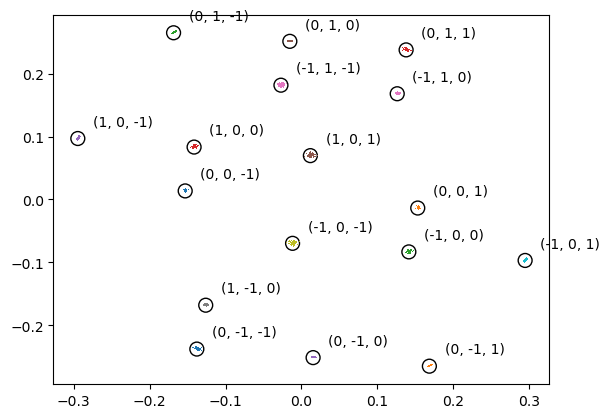

In [5]:
pl.figure()
for i in range(17):
    pl.text( g0[2,i]+0.02, g0[1,i]+0.02, tuple(hkls[i]) )
    pl.plot( glist[:,2,i], glist[:,1,i],',')
    pl.scatter( g0[2,i], g0[1,i], s=100, edgecolor='k', facecolor='none')

In [6]:
gall = np.hstack(glist)

## Case 1, Linear Least Squares on UB/UBI : Paciorek refinement

In [7]:
import ImageD11.indexing

In [8]:
ubi0 = np.linalg.inv( U0.dot( ucell.B ) )
ubi0fit = ImageD11.indexing.refine( ubi0, g0.T, 0.05 )
ubilistfit = ImageD11.indexing.refine( ubi0, gall.T, 0.05 )

In [9]:
cp = [ ImageD11.indexing.ubitocellpars( ubi ) for ubi in ( ubi0, ubi0fit, ubilistfit ) ] 
for cell in cp:
    print( " % .12f "*6%cell )
    print( " % .12f "*6%tuple(cell-np.array(cp[0]))  )
    print( )

  4.500000000000   4.500000000000   5.200000000000   90.000000000000   90.000000000000   120.000000000000 
  0.000000000000   0.000000000000   0.000000000000   0.000000000000   0.000000000000   0.000000000000 

  4.500000000000   4.500000000000   5.200000000000   90.000000000000   90.000000000000   120.000000000000 
 -0.000000000000   0.000000000000   0.000000000000   0.000000000000   0.000000000000   0.000000000000 

  4.500382022298   4.499900584620   5.200060889414   90.003883426654   90.000073160248   119.999776424643 
  0.000382022298  -0.000099415380   0.000060889414   0.003883426654   0.000073160248  -0.000223575357 



## Case 2, Metric tensor fit

In [10]:
modg2 = (gall**2).sum(axis=0)
h,k,l = hkls.T
gradients = np.array( ( h*h, k*k, l*l, 2*k*l, 2*h*l, 2*h*k ) )

In [11]:
modg2.shape, gradients.shape, np.tile( gradients, NGRAINS).shape

((66800,), (6, 668), (6, 66800))

In [12]:
lsqmat = gradients.dot( gradients.T )*NGRAINS
rhs = np.tile( gradients, NGRAINS ).dot( modg2 )
m = answer = np.linalg.inv( lsqmat ).dot( rhs )

In [13]:
mt1 = np.array( ( ( m[0],m[5],m[4] ),
                  ( m[5],m[1],m[3] ),
                  ( m[4],m[3],m[2] ) ) )
mt1, np.linalg.inv(mt1)

(array([[ 6.58436214e-02,  3.29218107e-02, -1.92214309e-17],
        [ 3.29218107e-02,  6.58436214e-02, -1.02149861e-17],
        [-1.92214309e-17, -1.02149861e-17,  3.69822485e-02]]),
 array([[ 2.02500000e+01, -1.01250000e+01,  7.72822782e-15],
        [-1.01250000e+01,  2.02500000e+01,  3.30874412e-16],
        [ 7.72822782e-15,  3.30874412e-16,  2.70400000e+01]]))

In [14]:
def mt_to_cp( g ):
    from math import acos, degrees, sqrt

    a = sqrt(g[0, 0])
    b = sqrt(g[1, 1])
    c = sqrt(g[2, 2])
    alpha = degrees(acos(g[1, 2] / b / c))
    beta = degrees(acos(g[0, 2] / a / c))
    gamma = degrees(acos(g[0, 1] / a / b))
    return a, b, c, alpha, beta, gamma

In [15]:
cp1 = mt_to_cp( np.linalg.inv(mt1) )

In [16]:
print( " % .12f "*6%cp1 )
print( " % .12f "*6%tuple(cp1-np.array(cp[0]))  )

  4.500000000000   4.500000000000   5.200000000000   90.000000000000   90.000000000000   120.000000000000 
 -0.000000000000   0.000000000000  -0.000000000000   0.000000000000  -0.000000000000  -0.000000000000 


In [17]:
# Using the metric tensor fit, we are immune to the banana shaped spot problem!

## Case 3, Laboratory metric in crystal

In [18]:
modh2 = (hkls**2).sum(axis=1)
x, y, z = gall
gradients = np.array( ( x*x, y*y, z*z, 2*y*z, 2*x*z, 2*x*y ) )

In [19]:
np.repeat( modh2, 100 ).shape, hkls.shape, modh2.shape, x.shape, gradients.shape, np.tile( modh2, NGRAINS ).shape

((66800,), (668, 3), (668,), (66800,), (6, 66800), (66800,))

In [20]:
lsqmat = gradients.dot( gradients.T )
rhs = gradients.dot( np.tile( modh2, NGRAINS ) )
m = answer = np.linalg.inv(lsqmat).dot( rhs )

In [21]:
mt2 = np.array( ( ( m[0],m[5],m[4] ),
                  ( m[5],m[1],m[3] ),
                  ( m[4],m[3],m[2] ) ) )
mt2

array([[22.9072314 , -8.33292655,  2.37464572],
       [-8.33292655, 18.88897156,  5.56046143],
       [ 2.37464572,  5.56046143, 25.7436426 ]])

In [22]:
ubi0.T.dot(ubi0)

array([[22.91080538, -8.33280237,  2.37534218],
       [-8.33280237, 18.88736055,  5.56249699],
       [ 2.37534218,  5.56249699, 25.74183408]])

## Relating the three fits: everything from here on by DeepSeek

With $g = U B h$, all three options are functions of the same 9 parameter object:

$$ ubi = (U B)^{-1} = B^{-1} U^T $$

- **Option 1** refines $ubi$ directly (9 parameters: 3 for the orientation, 6 for the strain)
- **Option 2** fits $|g|^2 = h^T G^* h$ and recovers

$$ G^* = B^T B = (U B)^T (U B) = (ubi\;ubi^T)^{-1} $$

the **left** square of $UB$ - the rotation cancels, so it gives the cell via
$G = (G^*)^{-1}$. It is exactly immune to the orientation spread (banana shaped spots).

- **Option 3** fits $|h|^2 = g^T W g$ and recovers

$$ W = (U B)^{-T} (U B)^{-1} = ubi^T\,ubi = U\,(B B^T)^{-1} U^T $$

the **right** square of $UB$ - this one *contains* the rotation $U$.

### The B gauge

$G^*$ fixes $B$ only through $B^T B$, so $B$ is defined up to a left rotation:
any $R B$ ($R$ orthogonal) gives the same cell. This gauge freedom is invisible
in the cell - it only decides where the rotation is stored ($U$ versus $B$).

The conventional ImageD11 $B$ is upper triangular, and for it $B^T B \ne B B^T$,
so in general $W \ne U G U^T$ and eigen-pairing $G$ directly against $W$ fails.

Requiring $B^T B = B B^T$ forces $B$ to be symmetric: from the SVD of any $B$,
the solutions are the 8 symmetric square roots $V\,\mathrm{diag}(\pm\sigma)\,V^T$
of $G^*$, and exactly one of them is positive definite - the *unique* choice
(degenerate eigenvalues of $G^*$ would leave more freedom):

$$ B_{sym} = (G^*)^{1/2}, \qquad B_{sym}^T B_{sym} = B_{sym} B_{sym}^T = G^* $$

In this gauge

$$ W = U_{sym}\,G\,U_{sym}^T $$

option 3 is literally the real space metric rotated into the lab frame.
The recovered orientation is gauge dependent: $U_{sym} = U_{std}\,R_{conv}$ with
$R_{conv} = B_{std}\,B_{sym}^{-1}$, a fixed rotation built from the cell.


In [23]:
# The two 6 parameter fits are the two Gram ("squares") of the same 9 parameter ubi:
print( "option 2 : G* = (ubi0.ubi0.T)^-1 ?", np.abs( mt1 - np.linalg.inv( ubi0.dot( ubi0.T ) ) ).max() )
print( "option 3 : W  =  ubi0.T.ubi0      ?", np.abs( mt2 - ubi0.T.dot( ubi0 ) ).max() )

option 2 : G* = (ubi0.ubi0.T)^-1 ? 1.249000902703301e-16
option 3 : W  =  ubi0.T.ubi0      ? 0.003573974558698012


## What option 3 gives on its own: eigenvalues

$B^T B$ and $B B^T$ share the same eigenvalues, so

$$ \mathrm{eig}(W^{-1}) = \mathrm{eig}(B B^T) = \mathrm{eig}(B^T B) = \mathrm{eig}(G^*) \qquad\mathrm{and}\qquad \mathrm{eig}(W) = \mathrm{eig}(G) $$

Option 3 alone therefore determines the eigenvalues of the metric tensors
(orientation invariant information - for this hexagonal cell the sorted
eigenvalues are $[2/(3a^2), 1/c^2, 2/a^2]$, so $a = \sqrt{2/\lambda_3}$,
$c = \sqrt{1/\lambda_2}$ once the symmetry says which eigenvalue is which),
but not the full cell.


eig(G*)  : [0.03292181 0.03698225 0.09876543]
eig(W^-1): [0.03292276 0.03698302 0.09875293]


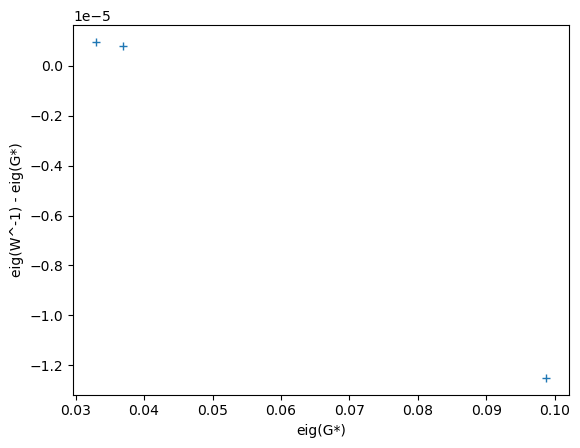

In [24]:
e1 = np.linalg.eigvalsh( mt1 )                  # G*   from option 2
e2 = np.linalg.eigvalsh( np.linalg.inv( mt2 ) ) # W^-1 from option 3
print( "eig(G*)  :", np.sort( e1 ) )
print( "eig(W^-1):", np.sort( e2 ) )
pl.figure()
pl.plot( np.sort( e1 ), np.sort( e2 ) - np.sort( e1 ), '+' )
pl.xlabel( "eig(G*)" )
pl.ylabel( "eig(W^-1) - eig(G*)" )
pl.show()

## Getting the cell and orientation back from option 3

Combine the two 6 parameter fits in the symmetric gauge:

1. From the option 2 cell, form $B_{sym} = (G^*)^{1/2}$ by eigen-decomposition
2. Since $W = U_{sym} G U_{sym}^T$ with $G = (G^*)^{-1}$, solve for $U_{sym}$
   by eigen-decomposition, then convert to any other B convention (e.g. the
   ImageD11 one) with $U_{std} = U_{sym} R_{conv}^T$

Since $W = V \Lambda V^T$ and $G = P \Lambda P^T$ share the same eigenvalues,
$U_{sym} = V S P^T$ where $S$ is a diagonal matrix of signs.
The 4 proper rotations are $U$ up to 180 degree rotations about the axes -
this ambiguity is intrinsic: $|h|^2$ data cannot distinguish $U$ from
$U\,R_{180}$, so all 4 candidates fit the data equally well.


In [25]:
def get_all_proper_rotations(B, C):
    """ Solve B = R C R^T for R, returning the 4 proper rotations
    (sign combinations that preserve det = +1) """
    val_B, vec_B = np.linalg.eigh( B )
    val_C, vec_C = np.linalg.eigh( C )
    idx_B = np.argsort( val_B )
    idx_C = np.argsort( val_C )
    V_B = vec_B[:, idx_B]
    V_C = vec_C[:, idx_C]
    if np.linalg.det( V_B @ V_C.T ) < 0:
        V_B[:, 0] *= -1
    rotations = []
    for s1, s2, s3 in [ (1,1,1), (-1,-1,1), (-1,1,-1), (1,-1,-1) ]:
        V = V_B.copy()
        V[:, 0] *= s1
        V[:, 1] *= s2
        V[:, 2] *= s3
        rotations.append( V @ V_C.T )
    return rotations

# Symmetric gauge: the unique B with B^T B = B B^T = G*
val, vec = np.linalg.eigh( mt1 )
Bsym = vec.dot( np.diag( np.sqrt( val ) ) ).dot( vec.T )
print( "Bsym symmetric                :", np.allclose( Bsym, Bsym.T ) )
print( "Bsym^T Bsym = G*, Bsym Bsym^T = G* :",
       np.allclose( Bsym.T.dot( Bsym ), mt1 ),
       np.allclose( Bsym.dot( Bsym.T ), mt1 ) )

# any other convention differs by a rotation: B_std = Rconv . Bsym
Rconv = ucell.B.dot( np.linalg.inv( Bsym ) )
print( "Rconv is a proper rotation    :", np.allclose( Rconv.dot( Rconv.T ), np.eye(3) ),
       "  det = % .3f"%np.linalg.det( Rconv ) )

Bsym symmetric                : True
Bsym^T Bsym = G*, Bsym Bsym^T = G* : True True
Rconv is a proper rotation    : True   det =  1.000


In [26]:
# In the symmetric gauge  W = U_sym . G . U_sym^T , with G = G*^-1 :
G = np.linalg.inv( mt1 )
U_sym_true = U0.dot( Rconv )
print( "W - U_sym G U_sym^T (fitted vs exact):",
       np.abs( mt2 - U_sym_true.dot( G ).dot( U_sym_true.T ) ).max() )

Ucand = get_all_proper_rotations( mt2, G )
for i, R in enumerate( Ucand ):
    print( "candidate %d: det=% .2f   |R G R^T - W| = % .3g   |R - U_sym| = % .3g"%(
        i, np.linalg.det( R ), np.abs( R.dot( G ).dot( R.T ) - mt2 ).max(),
        np.abs( R - U_sym_true ).max() ) )
    print( "  diag:", np.diag( R ) )
print( "truth diag(U_sym):", np.diag( U_sym_true ) )

# back to the ImageD11 gauge for comparison with U0:
U_opt3 = min( Ucand, key = lambda R : np.abs( R - U_sym_true ).max() ).dot( Rconv.T )
print( "|U_opt3 - U0| :", np.abs( U_opt3 - U0 ).max() )

W - U_sym G U_sym^T (fitted vs exact): 0.003573974558623405
candidate 0: det= 1.00   |R G R^T - W| =  0.000889   |R - U_sym| =  1.59
  diag: [-0.01275809  0.06926116 -0.79624781]
candidate 1: det= 1.00   |R G R^T - W| =  0.000889   |R - U_sym| =  1.99
  diag: [-0.79930666 -0.99506762  0.79624781]
candidate 2: det= 1.00   |R G R^T - W| =  0.000889   |R - U_sym| =  1.59
  diag: [ 0.01275809 -0.06926116 -0.79624781]
candidate 3: det= 1.00   |R G R^T - W| =  0.000889   |R - U_sym| =  0.000329
  diag: [0.79930666 0.99506762 0.79624781]
truth diag(U_sym): [0.79934297 0.99508788 0.79631746]
|U_opt3 - U0| : 0.0003290734901420511


In [27]:
# Option 1 recovers U from the fitted ubi : ubi = B^-1 U^T  =>  U = (B . ubi)^T
U_opt1_clean  = ( ucell.B.dot( ubi0fit ) ).T
U_opt1_spread = ( ucell.B.dot( ubilistfit ) ).T
print( "|U_opt1(clean)  - U0| :", np.abs( U_opt1_clean  - U0 ).max() )
print( "|U_opt1(spread) - U0| :", np.abs( U_opt1_spread - U0 ).max() )

|U_opt1(clean)  - U0| : 9.992007221626409e-16
|U_opt1(spread) - U0| : 0.00045767487251235917


In [28]:
# Comparison of the fitted results
truth = np.array( [ a, a, c, 90, 90, 120 ] )
print( "Cell parameter errors (fitted - truth):" )
for name, ubi in [ ( "option 1, clean  ", ubi0fit ),
                   ( "option 1, spread ", ubilistfit ) ]:
    print( name, " % .3e "*6 % tuple( ImageD11.indexing.ubitocellpars( ubi ) - truth ) )
print( "option 2, spread ", " % .3e "*6 % tuple( cp1 - truth ) )

print( )
print( "Orientation errors |U_fit - U0| (max abs):" )
print( "  option 1, clean             :", np.abs( U_opt1_clean  - U0 ).max() )
print( "  option 1, spread            :", np.abs( U_opt1_spread - U0 ).max() )
print( "  option 3, best of 4 cands   :", np.abs( U_opt3 - U0 ).max() )
print( "  option 3, all 4 fit |h|^2 equally well (180 degree ambiguity)" )

Cell parameter errors (fitted - truth):
option 1, clean    -3.553e-15   0.000e+00   2.665e-15   0.000e+00   1.421e-14   1.421e-14 
option 1, spread    3.820e-04  -9.942e-05   6.089e-05   3.883e-03   7.316e-05  -2.236e-04 
option 2, spread   -1.776e-15   0.000e+00  -5.329e-15   0.000e+00  -1.421e-14  -8.527e-14 

Orientation errors |U_fit - U0| (max abs):
  option 1, clean             : 9.992007221626409e-16
  option 1, spread            : 0.00045767487251235917
  option 3, best of 4 cands   : 0.0003290734901420511
  option 3, all 4 fit |h|^2 equally well (180 degree ambiguity)


## Conclusions

- **Option 2** is exactly immune to the orientation spread: the cell comes back
  with zero error because $|g|^2$ does not involve $U$.
- **Option 1** recovers the cell and the orientation with tiny errors -
  the 9 parameter fit averages the spread.
- **Option 3** gives the metric eigenvalues and the orientation $U$ (up to the
  unavoidable 180 degree ambiguity) with ~1e-3 errors. It is *not* immune to the
  spread, since $W$ depends on $U$ for each grain.
- The orientation is only defined up to the $B$ gauge ($B \to R B$): the cell is
  gauge invariant. The symmetric gauge $B = (G^*)^{1/2}$ is the unique one in
  which $W = U G U^T$ - option 3 is then the rotated real space metric.


## Human conclusion

This is interesting but it is not clear whether it is useful. The two six parameter fits both recover the eigenvalues of the metric, and so the mismatch between the left and right squares give a measure of the precision of the result. Coupling with the conventional UBI fit, you can figure out the 180 degree rotations and do any matching to derive U.

In the event of inconsistent left/right fits, I wonder if this is trying to tell us something about the impact of orientation spread on strain.

The philosophical motivation behind this is to fit an "orientation" without ever using a sin or cos function, or pi, or entering into one of the SO(3) spaces like quaternions, etc. Behind this story of squaring there was some discussion based on Wildberger's youtube videos about quadrance and spread, and how to apply that to crystallographic fitting.

The symmetric B matrix came up frequently when trying to do finite strains. The non-symmetric B matrix conventions are a source of endless problems. Unfortunately the symmetric B matrices are unfamiliar and difficult to understand in the presence of strains. Hexagonal axes do not match any laboratory directions:

array([[ 2.47856683e-01,  6.64129979e-02, -4.11029274e-17],
       [ 6.64129979e-02,  2.47856683e-01, -1.70055049e-17],
       [-4.11029274e-17, -1.70055049e-17,  1.92307692e-01]])

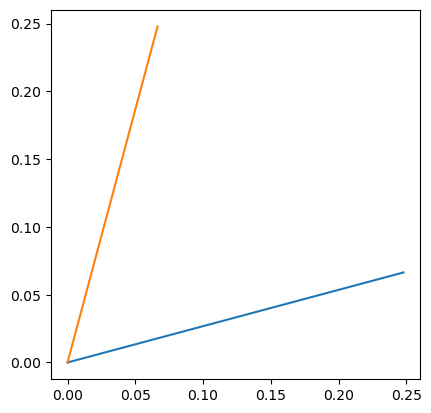

In [29]:
pl.figure()
pl.plot([0,Bsym[0,0]], [0,Bsym[0,1]],'-')
pl.plot([0,Bsym[1,0]], [0,Bsym[1,1]],'-')
pl.gca().set(aspect='equal')
Bsym